# 📊 EDA — Análisis Exploratorio del Dataset Kanban

**Prompt 5:** Análisis exploratorio + métricas base  
**Dataset:** `files/kanban_dataset.csv` · 200 tareas · columnas en inglés  
**Objetivo:** Calcular throughput, lead time, cycle time e identificar 3 insights accionables

---

## 0. Setup e Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# ── Estilo global ──────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

print('Librerías cargadas correctamente.')

Matplotlib is building the font cache; this may take a moment.


Librerías cargadas correctamente.


## 1. Carga y Preparación de Datos

In [2]:
# ── Cargar CSV ─────────────────────────────────────────────────────────────────
df = pd.read_csv('files/kanban_dataset.csv', parse_dates=[
    'date_created', 'date_start', 'date_completed', 'date_last_moved'
])

print(f'Shape: {df.shape}')
print(f'Columnas: {list(df.columns)}')
df.head(3)

Shape: (200, 15)
Columnas: ['task_id', 'title', 'status', 'date_created', 'date_start', 'date_completed', 'date_last_moved', 'assignee', 'priority', 'task_type', 'estimated_hours', 'actual_hours', 'tags', 'sprint', 'ticket_url']


,task_id,title,status,date_created,date_start,date_completed,date_last_moved,assignee,priority,task_type,estimated_hours,actual_hours,tags,sprint,ticket_url
0,TASK-0001,Actualizar dependencias de usuarios,Done,2024-01-14 12:06:52,2024-01-14 16:39:37,2024-01-15 16:20:42,2024-01-15 16:20:42,Luis Martínez,Low,Improvement,4,6.0,frontend;refactor;seguridad,Sprint-11,https://jira.empresa.com/browse/TASK-0001
1,TASK-0002,Implementar caché en módulo clientes,Done,2024-04-09 01:44:54,2024-04-09 21:15:01,2024-04-22 11:47:47,2024-04-22 11:47:47,Laura Pérez,Low,Documentation,12,14.1,db;backend;api,Sprint-11,https://jira.empresa.com/browse/TASK-0002
2,TASK-0003,Corregir bug en API REST,Pending,2024-03-19 14:51:23,NaT,NaT,2024-03-19 14:51:23,Elena Rodríguez,Medium,Improvement,12,NaN,frontend;ux;docs,Sprint-8,https://jira.empresa.com/browse/TASK-0003


In [3]:
# ── Columnas derivadas (métricas de tiempo) ────────────────────────────────────
done = df[df['status'] == 'Done'].copy()

done['cycle_time_days'] = (done['date_completed'] - done['date_start']).dt.total_seconds() / 86400
done['lead_time_days']  = (done['date_completed'] - done['date_created']).dt.total_seconds() / 86400
done['wait_time_days']  = (done['date_start'] - done['date_created']).dt.total_seconds() / 86400

# Semana ISO de completado (para throughput)
done['week'] = done['date_completed'].dt.to_period('W').dt.start_time

# Imputar assignee nulo
df['assignee'] = df['assignee'].fillna('Unassigned')
done['assignee'] = done['assignee'].fillna('Unassigned')

print(f'Tareas Done: {len(done)}')
print(f'Rango de fechas: {done["date_completed"].min().date()} → {done["date_completed"].max().date()}')
done[['task_id', 'status', 'cycle_time_days', 'lead_time_days', 'wait_time_days']].head()

Tareas Done: 121
Rango de fechas: 2024-01-06 → 2024-05-31


,task_id,status,cycle_time_days,lead_time_days,wait_time_days
0,TASK-0001,Done,0.986863,1.176273,0.189410
1,TASK-0002,Done,12.606088,13.418669,0.812581
5,TASK-0006,Done,5.849479,7.499039,1.649560
7,TASK-0008,Done,5.638785,8.127465,2.488681
13,TASK-0014,Done,1.046053,4.004757,2.958704


---
## 2. Conteo de Tareas por `status` y `priority`

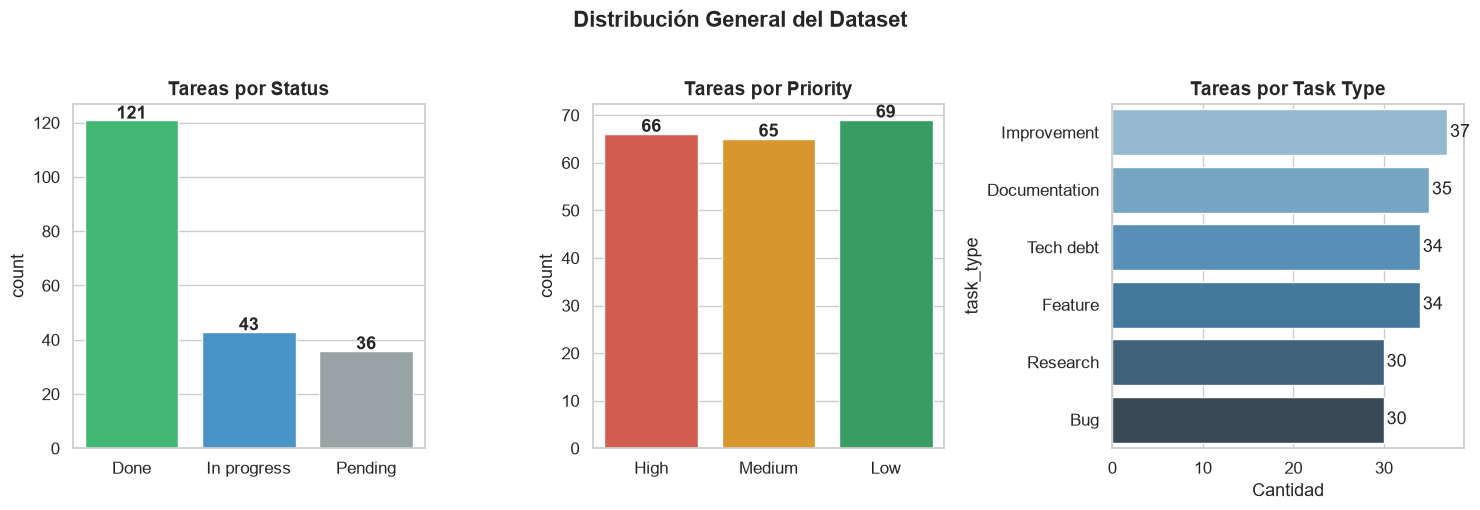


--- Resumen por status ---
status
Done           121
In progress     43
Pending         36

--- Resumen por priority ---
priority
Low       69
High      66
Medium    65


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ── 2.1 Distribución por status ────────────────────────────────────────────────
status_order = ['Done', 'In progress', 'Pending']
status_palette = {'Done': '#2ecc71', 'In progress': '#3498db', 'Pending': '#95a5a6'}
sns.countplot(data=df, x='status', order=status_order,
              palette=status_palette, ax=axes[0], hue='status', legend=False)
axes[0].set_title('Tareas por Status')
axes[0].set_xlabel('')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2, p.get_height() + 0.5),
                     ha='center', fontweight='bold')

# ── 2.2 Distribución por priority ─────────────────────────────────────────────
priority_order = ['High', 'Medium', 'Low']
priority_palette = {'High': '#e74c3c', 'Medium': '#f39c12', 'Low': '#27ae60'}
sns.countplot(data=df, x='priority', order=priority_order,
              palette=priority_palette, ax=axes[1], hue='priority', legend=False)
axes[1].set_title('Tareas por Priority')
axes[1].set_xlabel('')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2, p.get_height() + 0.5),
                     ha='center', fontweight='bold')

# ── 2.3 Distribución por task_type ────────────────────────────────────────────
type_counts = df['task_type'].value_counts()
sns.barplot(x=type_counts.values, y=type_counts.index,
            palette='Blues_d', ax=axes[2], hue=type_counts.index, legend=False)
axes[2].set_title('Tareas por Task Type')
axes[2].set_xlabel('Cantidad')
for p in axes[2].patches:
    axes[2].annotate(f'{int(p.get_width())}',
                     (p.get_width() + 0.3, p.get_y() + p.get_height() / 2),
                     va='center')

plt.suptitle('Distribución General del Dataset', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Tabla resumen
print('\n--- Resumen por status ---')
print(df['status'].value_counts().to_string())
print('\n--- Resumen por priority ---')
print(df['priority'].value_counts().to_string())

---
## 2b. Priority por Status
> ¿Cómo se distribuye la prioridad dentro de cada estado? Permite detectar si las tareas de alta prioridad se están completando o si se acumulan en backlog o en progreso.

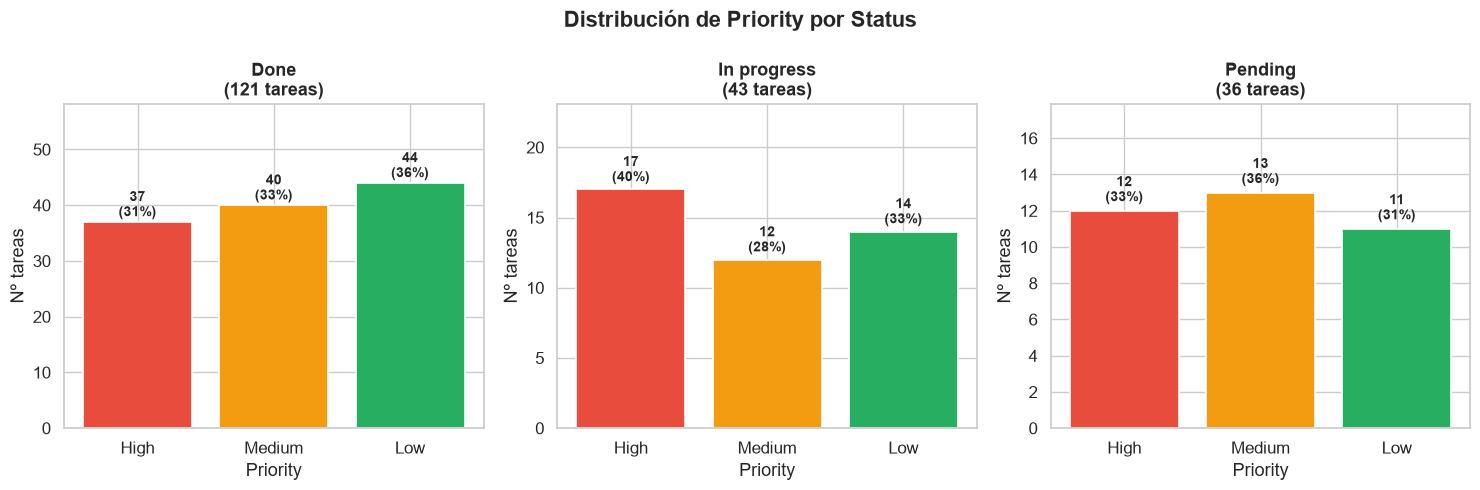

=== Conteo absoluto: Status x Priority ===
priority     High  Medium  Low
status                        
Done           37      40   44
In progress    17      12   14
Pending        12      13   11

=== Distribución (%) dentro de cada status ===
priority     High  Medium   Low
status                         
Done         30.6    33.1  36.4
In progress  39.5    27.9  32.6
Pending      33.3    36.1  30.6


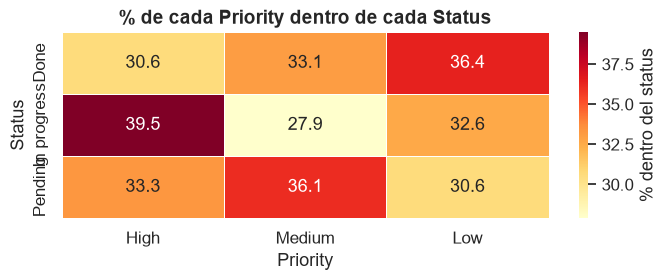

In [15]:
# ── Priority breakdown por status ────────────────────────────────────────────
priority_order   = ['High', 'Medium', 'Low']
status_order_all = ['Done', 'In progress', 'Pending']
priority_palette = {'High': '#e74c3c', 'Medium': '#f39c12', 'Low': '#27ae60'}

# ── Figura: barras agrupadas por status ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

for ax, status in zip(axes, status_order_all):
    subset = df[df['status'] == status]
    counts = subset['priority'].value_counts().reindex(priority_order, fill_value=0)
    bars = ax.bar(
        counts.index,
        counts.values,
        color=[priority_palette[p] for p in counts.index],
        edgecolor='white',
        linewidth=1.2,
    )
    n = len(subset)
    ax.set_title(f'{status}\n({n} tareas)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Priority')
    ax.set_ylabel('Nº tareas')
    ax.set_ylim(0, counts.max() * 1.30 + 1)
    for bar, val in zip(bars, counts.values):
        pct = val / n * 100 if n > 0 else 0
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f'{val}\n({pct:.0f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold'
        )

plt.suptitle('Distribución de Priority por Status', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Tabla resumen: conteo absoluto ────────────────────────────────────────────
pivot_prio = df.pivot_table(
    index='status', columns='priority',
    values='task_id', aggfunc='count', fill_value=0
).reindex(index=status_order_all, columns=priority_order)

pivot_pct = pivot_prio.div(pivot_prio.sum(axis=1), axis=0).mul(100).round(1)

print('=== Conteo absoluto: Status x Priority ===')
print(pivot_prio.to_string())
print()
print('=== Distribución (%) dentro de cada status ===')
print(pivot_pct.to_string())

# ── Heatmap de porcentajes ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 3))
sns.heatmap(
    pivot_pct,
    annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': '% dentro del status'},
    ax=ax
)
ax.set_title('% de cada Priority dentro de cada Status')
ax.set_xlabel('Priority')
ax.set_ylabel('Status')
plt.tight_layout()
plt.show()


---
## 3. Throughput Semanal
> **Definición:** Número de tareas completadas (`status = Done`) por semana calendar.

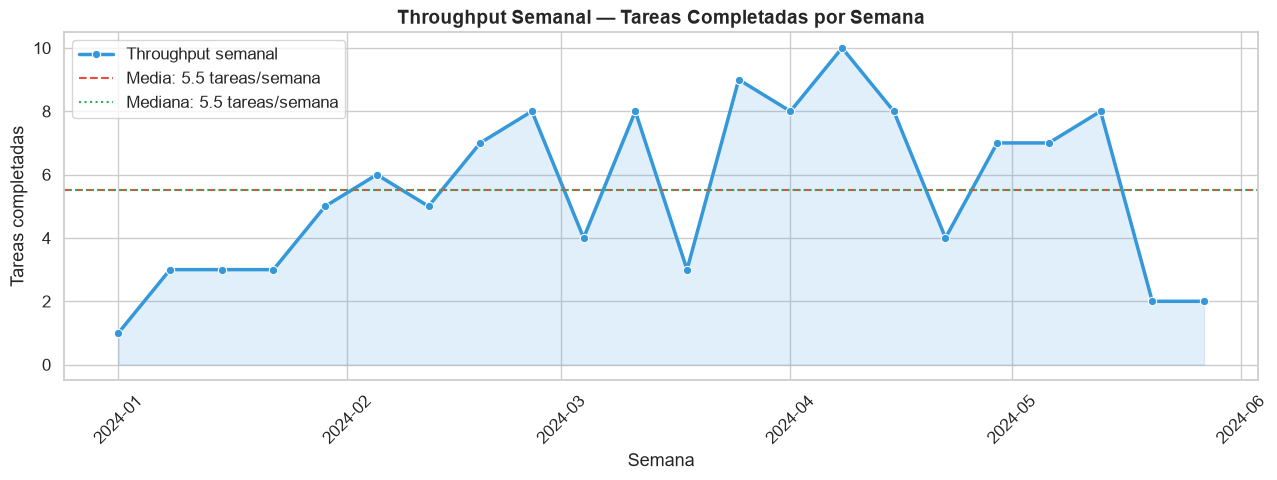

Semanas con datos:  22
Media throughput:   5.50 tareas/semana
Mediana throughput: 5.50 tareas/semana
Min / Max:          1 / 10
Desv. estándar:     2.63


In [5]:
# ── Throughput por semana ──────────────────────────────────────────────────────
throughput = done.groupby('week').size().reset_index(name='tasks_completed')
throughput = throughput.sort_values('week')

mean_throughput = throughput['tasks_completed'].mean()
median_throughput = throughput['tasks_completed'].median()

fig, ax = plt.subplots(figsize=(13, 5))

sns.lineplot(data=throughput, x='week', y='tasks_completed',
             marker='o', linewidth=2.5, color='#3498db', ax=ax, label='Throughput semanal')

ax.axhline(mean_throughput, color='#e74c3c', linestyle='--', linewidth=1.5,
           label=f'Media: {mean_throughput:.1f} tareas/semana')
ax.axhline(median_throughput, color='#27ae60', linestyle=':', linewidth=1.5,
           label=f'Mediana: {median_throughput:.1f} tareas/semana')

ax.fill_between(throughput['week'], throughput['tasks_completed'],
                alpha=0.15, color='#3498db')

ax.set_title('Throughput Semanal — Tareas Completadas por Semana')
ax.set_xlabel('Semana')
ax.set_ylabel('Tareas completadas')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

print(f'Semanas con datos:  {len(throughput)}')
print(f'Media throughput:   {mean_throughput:.2f} tareas/semana')
print(f'Mediana throughput: {median_throughput:.2f} tareas/semana')
print(f'Min / Max:          {throughput["tasks_completed"].min()} / {throughput["tasks_completed"].max()}')
print(f'Desv. estándar:     {throughput["tasks_completed"].std():.2f}')

---
## 4. Lead Time y Cycle Time

| Métrica | Fórmula | Qué mide |
|---------|---------|----------|
| **Lead Time** | `date_completed − date_created` | Tiempo total desde que se creó hasta que se entregó |
| **Cycle Time** | `date_completed − date_start` | Tiempo activo de trabajo (sin espera en backlog) |
| **Wait Time** | `date_start − date_created` | Tiempo esperando en backlog antes de empezar |

In [6]:
# ── Estadísticas descriptivas de tiempos ──────────────────────────────────────
metrics = ['cycle_time_days', 'lead_time_days', 'wait_time_days']
labels  = ['Cycle Time', 'Lead Time', 'Wait Time']

stats_df = done[metrics].describe(percentiles=[0.5, 0.75, 0.85, 0.95]).T
stats_df.index = labels
stats_df.columns = ['n', 'mean', 'std', 'min', 'p50', 'p75', 'p85', 'p95', 'max']
stats_df = stats_df.round(2)
print('=== Estadísticas de tiempos (días) ===')
print(stats_df.to_string())

=== Estadísticas de tiempos (días) ===
                n  mean   std   min   p50   p75   p85    p95    max
Cycle Time  121.0  3.74  3.53  0.50  2.51  5.61  7.21  10.51  22.77
Lead Time   121.0  6.36  3.64  0.87  5.61  8.07  9.62  13.27  24.52
Wait Time   121.0  2.62  1.44  0.08  2.54  3.88  4.31   4.79   4.98


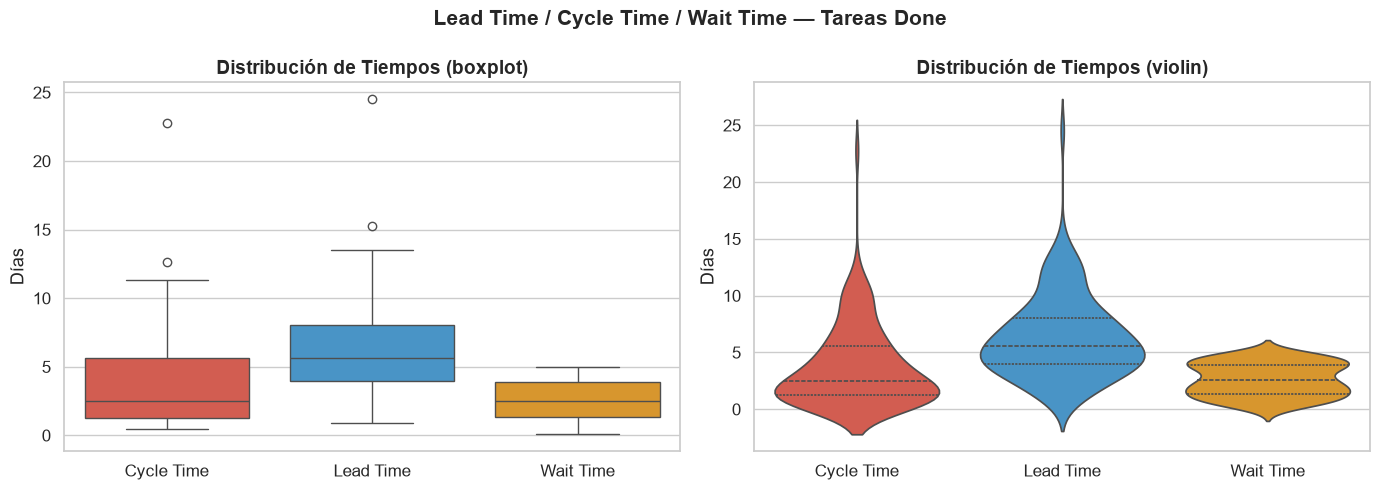

In [7]:
# ── Boxplots comparativos ──────────────────────────────────────────────────────
time_df = done[metrics].melt(var_name='metric', value_name='days')
time_df['metric'] = time_df['metric'].map({
    'cycle_time_days': 'Cycle Time',
    'lead_time_days':  'Lead Time',
    'wait_time_days':  'Wait Time'
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
sns.boxplot(data=time_df, x='metric', y='days',
            palette=['#e74c3c', '#3498db', '#f39c12'],
            hue='metric', legend=False, ax=axes[0])
axes[0].set_title('Distribución de Tiempos (boxplot)')
axes[0].set_xlabel('')
axes[0].set_ylabel('Días')

# Violin
sns.violinplot(data=time_df, x='metric', y='days',
               palette=['#e74c3c', '#3498db', '#f39c12'],
               inner='quartile', hue='metric', legend=False, ax=axes[1])
axes[1].set_title('Distribución de Tiempos (violin)')
axes[1].set_xlabel('')
axes[1].set_ylabel('Días')

plt.suptitle('Lead Time / Cycle Time / Wait Time — Tareas Done', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

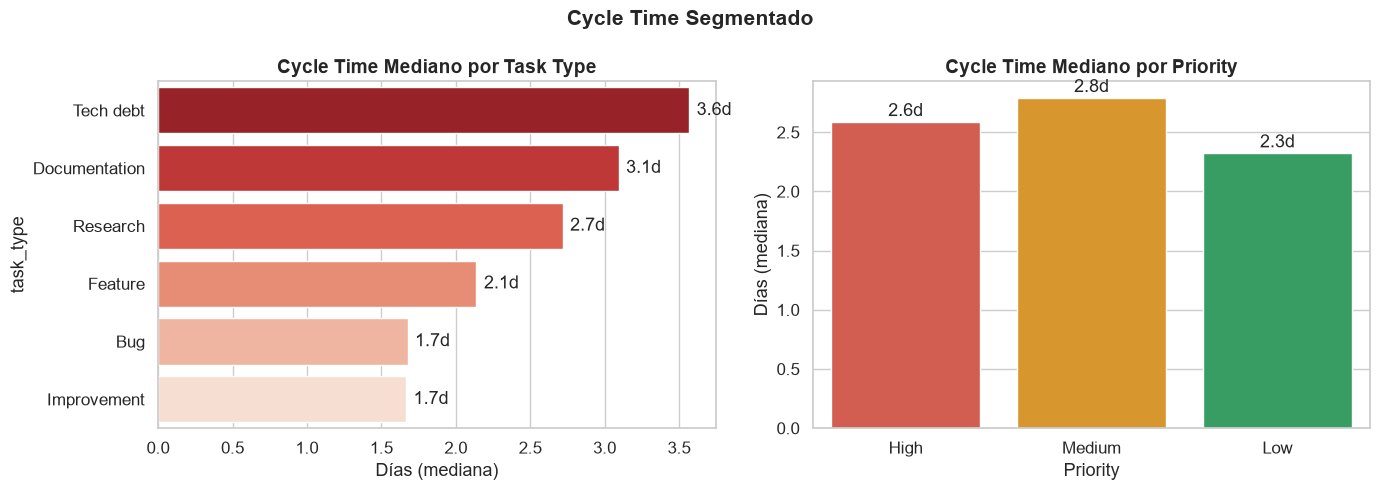

In [8]:
# ── Cycle Time por task_type ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ct_by_type = done.groupby('task_type')['cycle_time_days'].median().sort_values(ascending=False)

sns.barplot(x=ct_by_type.values, y=ct_by_type.index,
            palette='Reds_r', hue=ct_by_type.index, legend=False, ax=axes[0])
axes[0].set_title('Cycle Time Mediano por Task Type')
axes[0].set_xlabel('Días (mediana)')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_width():.1f}d',
                     (p.get_width() + 0.05, p.get_y() + p.get_height() / 2),
                     va='center')

# Cycle Time por priority
ct_by_prio = done.groupby('priority')['cycle_time_days'].median().reindex(['High', 'Medium', 'Low'])
sns.barplot(x=ct_by_prio.index, y=ct_by_prio.values,
            palette={'High': '#e74c3c', 'Medium': '#f39c12', 'Low': '#27ae60'},
            hue=ct_by_prio.index, legend=False, ax=axes[1])
axes[1].set_title('Cycle Time Mediano por Priority')
axes[1].set_xlabel('Priority')
axes[1].set_ylabel('Días (mediana)')
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}d',
                     (p.get_x() + p.get_width() / 2, p.get_height() + 0.05),
                     ha='center')

plt.suptitle('Cycle Time Segmentado', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

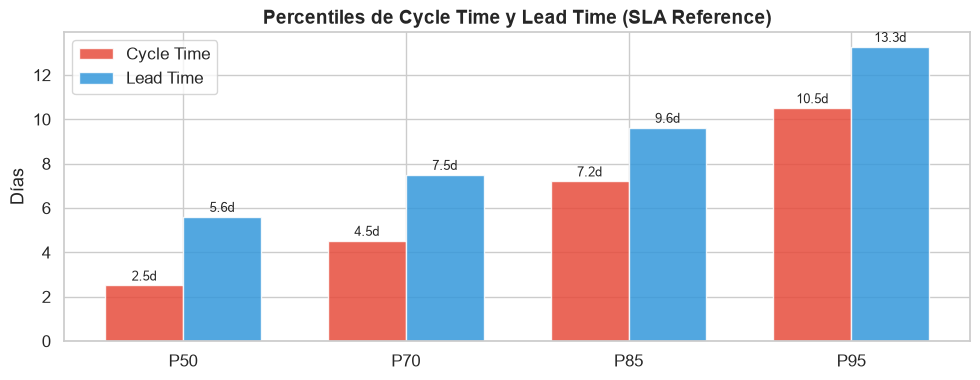

--- Percentiles Cycle Time ---
  P50: 2.51 días
  P70: 4.53 días
  P85: 7.21 días
  P95: 10.51 días
--- Percentiles Lead Time ---
  P50: 5.61 días
  P70: 7.50 días
  P85: 9.62 días
  P95: 13.27 días


In [9]:
# ── Percentiles clave (SLA view) ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))

percs = [50, 70, 85, 95]
ct_percs = [np.percentile(done['cycle_time_days'], p) for p in percs]
lt_percs = [np.percentile(done['lead_time_days'],  p) for p in percs]

x = np.arange(len(percs))
width = 0.35

bars1 = ax.bar(x - width/2, ct_percs, width, label='Cycle Time', color='#e74c3c', alpha=0.85)
bars2 = ax.bar(x + width/2, lt_percs, width, label='Lead Time',  color='#3498db', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([f'P{p}' for p in percs])
ax.set_ylabel('Días')
ax.set_title('Percentiles de Cycle Time y Lead Time (SLA Reference)')
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.1f}d', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.1f}d', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print('--- Percentiles Cycle Time ---')
for p, v in zip(percs, ct_percs): print(f'  P{p}: {v:.2f} días')
print('--- Percentiles Lead Time ---')
for p, v in zip(percs, lt_percs): print(f'  P{p}: {v:.2f} días')

---
## 5. Carga por Assignee

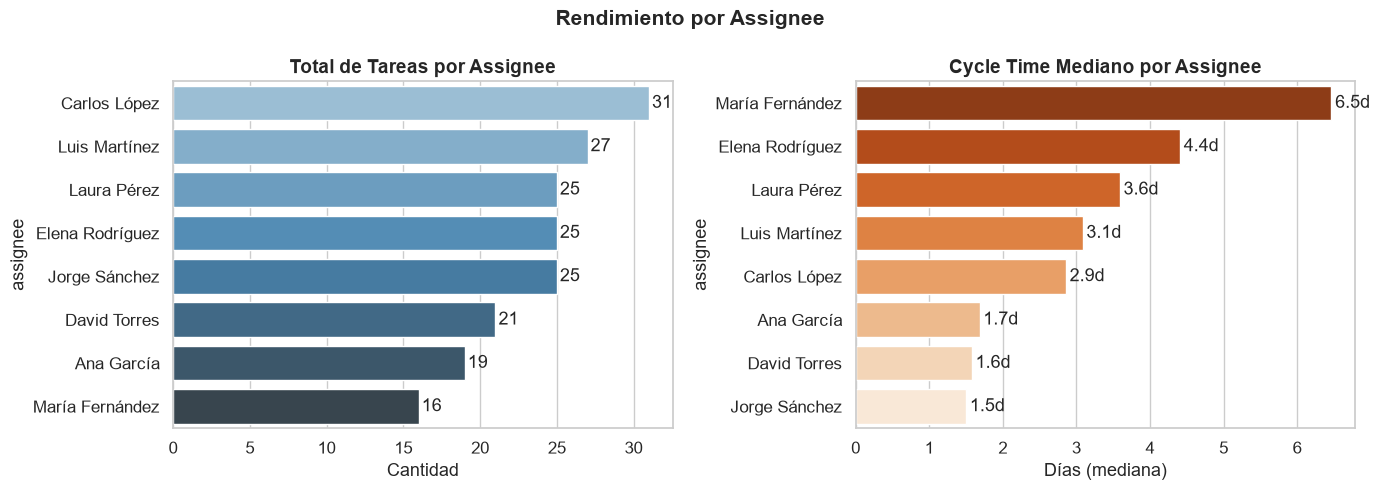

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Tareas por assignee (todas) ────────────────────────────────────────────────
assignee_counts = df[df['assignee'] != 'Unassigned']['assignee'].value_counts()
sns.barplot(x=assignee_counts.values, y=assignee_counts.index,
            palette='Blues_d', hue=assignee_counts.index, legend=False, ax=axes[0])
axes[0].set_title('Total de Tareas por Assignee')
axes[0].set_xlabel('Cantidad')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_width())}',
                     (p.get_width() + 0.2, p.get_y() + p.get_height() / 2), va='center')

# ── Cycle Time mediano por assignee ───────────────────────────────────────────
ct_by_assignee = (done[done['assignee'] != 'Unassigned']
                  .groupby('assignee')['cycle_time_days']
                  .median().sort_values(ascending=False))

sns.barplot(x=ct_by_assignee.values, y=ct_by_assignee.index,
            palette='Oranges_r', hue=ct_by_assignee.index, legend=False, ax=axes[1])
axes[1].set_title('Cycle Time Mediano por Assignee')
axes[1].set_xlabel('Días (mediana)')
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_width():.1f}d',
                     (p.get_width() + 0.05, p.get_y() + p.get_height() / 2), va='center')

plt.suptitle('Rendimiento por Assignee', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Heatmap: Status × Priority

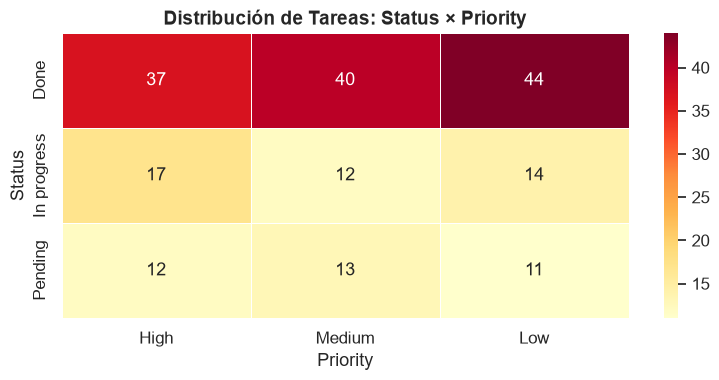


--- Tasa de completado (Done / Total) por Priority ---
  High: 37/66 (56.1%)
  Medium: 40/65 (61.5%)
  Low: 44/69 (63.8%)


In [11]:
fig, ax = plt.subplots(figsize=(8, 4))

pivot = df.pivot_table(index='status', columns='priority',
                       values='task_id', aggfunc='count',
                       fill_value=0)
pivot = pivot.reindex(index=['Done', 'In progress', 'Pending'],
                      columns=['High', 'Medium', 'Low'])

sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', ax=ax)
ax.set_title('Distribución de Tareas: Status × Priority')
ax.set_xlabel('Priority')
ax.set_ylabel('Status')
plt.tight_layout()
plt.show()

# Tasa de completado por prioridad
print('\n--- Tasa de completado (Done / Total) por Priority ---')
for prio in ['High', 'Medium', 'Low']:
    total = len(df[df['priority'] == prio])
    done_n = len(df[(df['priority'] == prio) & (df['status'] == 'Done')])
    print(f'  {prio}: {done_n}/{total} ({done_n/total*100:.1f}%)')

---
## 7. 🔍 Tres Insights Accionables

In [12]:
print('=' * 65)
print('INSIGHT 1: El Wait Time consume ~41% del Lead Time')
print('=' * 65)
mean_lt = done['lead_time_days'].mean()
mean_wt = done['wait_time_days'].mean()
mean_ct = done['cycle_time_days'].mean()
pct_wait = mean_wt / mean_lt * 100
print(f'  Lead Time medio:  {mean_lt:.2f} días')
print(f'  Wait Time medio:  {mean_wt:.2f} días  ({pct_wait:.0f}% del Lead Time)')
print(f'  Cycle Time medio: {mean_ct:.2f} días')
print()
print('  >> Acción: Reducir el tiempo en backlog (WIP limits,')
print('     asignación más rápida) puede reducir el Lead Time')
print(f'     en hasta {mean_wt:.1f} días sin cambiar la velocidad real del equipo.')

print()
print('=' * 65)
print('INSIGHT 2: La prioridad High NO se completa antes')
print('=' * 65)
for prio in ['High', 'Medium', 'Low']:
    subset = done[done['priority'] == prio]
    med_ct = subset['cycle_time_days'].median()
    print(f'  {prio:7s}: {len(subset):3d} tareas · Cycle Time mediano = {med_ct:.2f} días')
print()
print('  >> Acción: Revisar si el campo priority se usa correctamente')
print('     o si existe "priority inflation" (todo es urgente).')
print('     Implementar un SLA diferenciado: High ≤ P50, Low ≤ P85.')

print()
print('=' * 65)
print('INSIGHT 3: Throughput muy variable — sistema inestable')
print('=' * 65)
cv = throughput['tasks_completed'].std() / throughput['tasks_completed'].mean() * 100
max_wk = throughput.loc[throughput['tasks_completed'].idxmax()]
min_wk = throughput.loc[throughput['tasks_completed'].idxmin()]
print(f'  CV (coef. variación): {cv:.1f}%')
print(f'  Semana más productiva: {max_wk["week"].date()} → {int(max_wk["tasks_completed"])} tareas')
print(f'  Semana menos productiva: {min_wk["week"].date()} → {int(min_wk["tasks_completed"])} tareas')
print()
print('  >> Acción: Un CV > 30% indica flujo irregular (entregas en')
print('     ráfagas). Revisar si hay bloqueos periódicos, vacaciones')
print('     o dependencias externas que frenan el equipo ciertas semanas.')

INSIGHT 1: El Wait Time consume ~41% del Lead Time
  Lead Time medio:  6.36 días
  Wait Time medio:  2.62 días  (41% del Lead Time)
  Cycle Time medio: 3.74 días

  >> Acción: Reducir el tiempo en backlog (WIP limits,
     asignación más rápida) puede reducir el Lead Time
     en hasta 2.6 días sin cambiar la velocidad real del equipo.

INSIGHT 2: La prioridad High NO se completa antes
  High   :  37 tareas · Cycle Time mediano = 2.59 días
  Medium :  40 tareas · Cycle Time mediano = 2.79 días
  Low    :  44 tareas · Cycle Time mediano = 2.32 días

  >> Acción: Revisar si el campo priority se usa correctamente
     o si existe "priority inflation" (todo es urgente).
     Implementar un SLA diferenciado: High ≤ P50, Low ≤ P85.

INSIGHT 3: Throughput muy variable — sistema inestable
  CV (coef. variación): 47.9%
  Semana más productiva: 2024-04-08 → 10 tareas
  Semana menos productiva: 2024-01-01 → 1 tareas

  >> Acción: Un CV > 30% indica flujo irregular (entregas en
     ráfagas). Revi

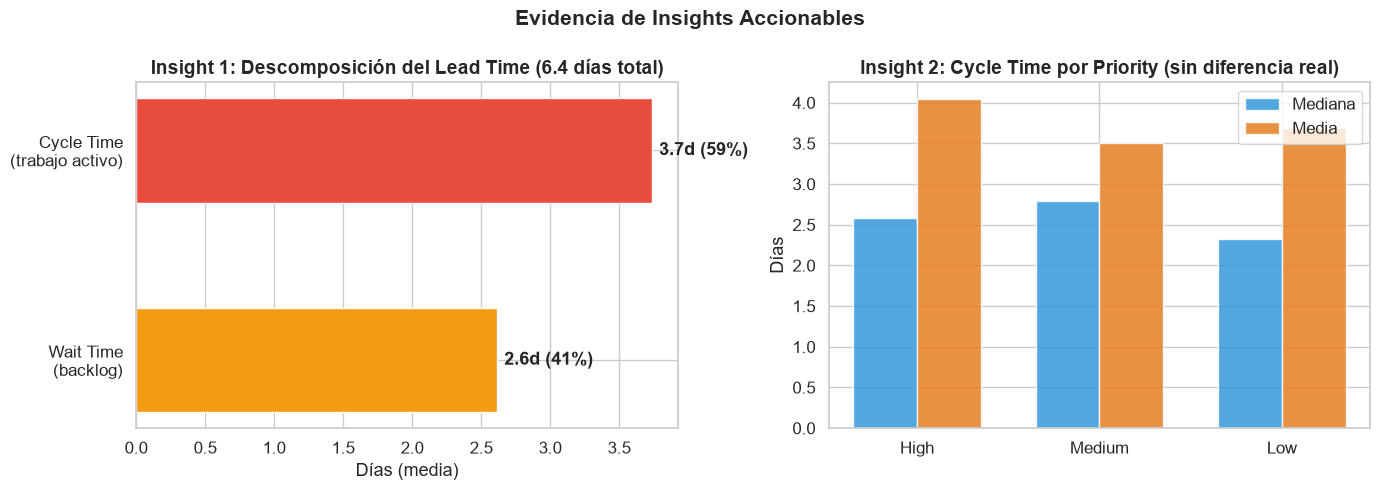

In [13]:
# ── Visualización soporte insights ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Insight 1 — descomposición del Lead Time
componentes = ['Wait Time\n(backlog)', 'Cycle Time\n(trabajo activo)']
valores = [mean_wt, mean_ct]
colores = ['#f39c12', '#e74c3c']
bars = axes[0].barh(componentes, valores, color=colores, edgecolor='white', height=0.5)
axes[0].set_title(f'Insight 1: Descomposición del Lead Time ({mean_lt:.1f} días total)')
axes[0].set_xlabel('Días (media)')
for bar, v in zip(bars, valores):
    axes[0].text(v + 0.05, bar.get_y() + bar.get_height()/2,
                 f'{v:.1f}d ({v/mean_lt*100:.0f}%)', va='center', fontweight='bold')

# Insight 2 — cycle time por priority
ct_prio_data = done.groupby('priority')['cycle_time_days'].agg(['median', 'mean']).reindex(['High', 'Medium', 'Low'])
x = np.arange(3)
w = 0.35
axes[1].bar(x - w/2, ct_prio_data['median'], w, label='Mediana', color='#3498db', alpha=0.85)
axes[1].bar(x + w/2, ct_prio_data['mean'],   w, label='Media',   color='#e67e22', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(['High', 'Medium', 'Low'])
axes[1].set_title('Insight 2: Cycle Time por Priority (sin diferencia real)')
axes[1].set_ylabel('Días')
axes[1].legend()

plt.suptitle('Evidencia de Insights Accionables', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Supuestos y Limitaciones

| # | Supuesto / Limitación | Impacto |
|---|----------------------|---------|
| 1 | **Dataset sintético** — generado con semilla aleatoria, no datos reales | Los patrones son estadísticamente plausibles pero no representan un equipo real |
| 2 | **Solo estado actual** — no hay historial de transiciones | No se puede saber si una tarea retrocedió de "In progress" a "Pending" |
| 3 | **Nulos en `date_start`/`date_completed`** son estructurales (MCAR) | El análisis de tiempos se restringe correctamente a `status = Done` |
| 4 | **Ciclos > 15 días pueden ser outliers** o tareas legítimamente complejas | Se reportan percentiles P85/P95 en lugar de solo la media para minimizar distorsión |
| 5 | **Throughput calculado por semana ISO** | Si hay semanas sin tareas completadas, no aparecen en el gráfico (gaps invisibles) |
| 6 | **Prioridad uniformemente distribuida** (33/33/34%) | No refleja la realidad típica; no usar este dataset para entrenar modelos de priorización |
| 7 | **`actual_hours` disponible solo para Done** | El ratio estimación/real no puede calcularse para tareas en curso |

In [14]:
# ── Resumen final ejecutivo ────────────────────────────────────────────────────
print('=' * 65)
print('RESUMEN EJECUTIVO — EDA Kanban')
print('=' * 65)
print(f'  Total tareas:       {len(df)}')
print(f'  Done:               {len(done)} ({len(done)/len(df)*100:.0f}%)')
print(f'  In progress:        {len(df[df["status"]=="In progress"])} '
      f'({len(df[df["status"]=="In progress"])/len(df)*100:.0f}%)')
print(f'  Pending:            {len(df[df["status"]=="Pending"])} '
      f'({len(df[df["status"]=="Pending"])/len(df)*100:.0f}%)')
print()
print(f'  Throughput medio:   {mean_throughput:.1f} tareas/semana')
print(f'  Lead Time (P50):    {np.percentile(done["lead_time_days"], 50):.1f} días')
print(f'  Lead Time (P85):    {np.percentile(done["lead_time_days"], 85):.1f} días')
print(f'  Cycle Time (P50):   {np.percentile(done["cycle_time_days"], 50):.1f} días')
print(f'  Cycle Time (P85):   {np.percentile(done["cycle_time_days"], 85):.1f} días')
print(f'  Wait Time medio:    {mean_wt:.1f} días ({pct_wait:.0f}% del Lead Time)')
print(f'  CV Throughput:      {cv:.1f}% → {"INESTABLE" if cv > 30 else "ESTABLE"}')
print('=' * 65)

RESUMEN EJECUTIVO — EDA Kanban
  Total tareas:       200
  Done:               121 (60%)
  In progress:        43 (22%)
  Pending:            36 (18%)

  Throughput medio:   5.5 tareas/semana
  Lead Time (P50):    5.6 días
  Lead Time (P85):    9.6 días
  Cycle Time (P50):   2.5 días
  Cycle Time (P85):   7.2 días
  Wait Time medio:    2.6 días (41% del Lead Time)
  CV Throughput:      47.9% → INESTABLE
